Parameter fitting
---

Now that we have the trained density ratios, it is time to build the full statistical model

<!-- $$ \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = \prod_{x_e\in \{x\}} \frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \bigg[\mu \cdot \lambda_\mathrm{sig} \cdot \underbrace{\frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model} + \lambda_\mathrm{bkg} \cdot \underbrace{\frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model}\bigg]$$ -->

$$-2 \ln \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = -2 \sum_{x_e\in \{x\}} \ln \bigg(\frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \bigg[\mu \cdot \lambda_\mathrm{sig} \cdot \underbrace{\frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model} + \lambda_\mathrm{bkg} \cdot \underbrace{\frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}}_\text{trained model}\bigg]\bigg)$$

which can be used for the final test statistic:

$$ t_\mu = -2 \big[ \ln L(\mu) - \ln L(\hat{\mu}) \big]$$

where the reference terms have canceled out. 

In this notebook, we will use the `nsbi-common-utils` to build the statistical model and perform fits with the test statistic.  


In [1]:
import os
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import pickle
import matplotlib.pyplot as plt
from nsbi_common_utils.training.utils import load_trained_model


Insert the path to the downloaded dataset (see README for download link)

In [2]:
BASE_PATH = "./data_nsbi_tutorial/"
BASE_PATH = "./dataframes/"

Load the signal and background datasets

In [3]:
signal = pd.read_parquet(f"{BASE_PATH}/signal_10.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

Get the total yields for the estimation of $\lambda_\mathrm{sig}, \lambda_\mathrm{bkg}$ to be used in the statistical model

In [4]:
TOTAL_YIELD = {}
TOTAL_YIELD["signal"] = signal.weight.sum()
TOTAL_YIELD["background"] = background.weight.sum()

Since we are using a weighted dataset, we also need a weighted sum of log-likelihoods and thus need to extract the weight vector for the data we are fitting

$$-2 \ln L(\mu) = -2 \sum_{x_e\in \{x\}} w_e \cdot \ln \bigg(\frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \bigg[\mu \cdot \lambda_\mathrm{sig} \cdot \frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)} + \lambda_\mathrm{bkg} \cdot \frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}\bigg]\bigg)$$

In [5]:
asimov_dataset = pd.concat([background, signal], ignore_index=True).astype('float32').copy()
weights_asimov = np.array(asimov_dataset.weight)
PATH_TO_WEIGHTS = "saved_weights/asimov_weight_array.npy"
os.makedirs(os.path.dirname(PATH_TO_WEIGHTS), exist_ok=True)
np.save(PATH_TO_WEIGHTS, weights_asimov)

Features used in the training setup

In [6]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

Set the path to where the estimated density ratios from trained models will be saved, to be later used in the fits

In [7]:
PATH_TO_RATIOS = {}
PATH_TO_RATIOS["signal"] = "saved_ratios_asimov/ratio_SigvsRef.npy"
PATH_TO_RATIOS["background"] = "saved_ratios_asimov/ratio_BkgvsRef.npy"

In [8]:
for path in PATH_TO_RATIOS.values():
    os.makedirs(os.path.dirname(path), exist_ok=True)

Load the trained models, and evaluate on data. For this example, we use the Asimov data only.

A simple call to `nsbi_common_utils.training.utils.predict_with_model` with the path to saved neural networks is enough to get the predictions. 

Since the networks were trained with the binary cross-entropy loss, their output needs to be converted to the density ratio via a simple monotonic transformation:

$$ \hat{r} (x) = \frac{\hat{s}(x)}{1.0 - \hat{s}(x)}

In [ ]:

path_to_saved_scaler = f"models_SigvsRef/model_scaler0.bin"
path_to_saved_model  = f"models_SigvsRef/model0.onnx"

scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

prediction = nsbi_common_utils.training.utils.predict_with_model(
    asimov_dataset[training_features],
    scaler=scaler,
    model=model
)

prediction_ratio = prediction / (1.0 - prediction)
np.save(PATH_TO_RATIOS["signal"], prediction_ratio)


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [10]:
path_to_saved_scaler = f"models_BkgvsRef/model_scaler0.bin"
path_to_saved_model  = f"models_BkgvsRef/model0.onnx"

scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

prediction = nsbi_common_utils.training.utils.predict_with_model(asimov_dataset[training_features], 
                                                                scaler = scaler, 
                                                                model = model)

prediction_ratio = prediction / (1.0 - prediction)
np.save(PATH_TO_RATIOS["background"], prediction_ratio)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Build a workspace
---

Now its time to build a workspace object, which is a serialization of the statistical model, that can be used to perform parameter fits. 

The following JSON serialization standard has been heavily inspired by the `pyhf` framework by design - allowing future avenues of interoperability.

Key differences:

- a new `type` field has been added to distinguish SBI region from binned regions (e.g. control regions or combination channels)
- the `data` fields now store the total event yield in the SBI region instead of the binned arrays
- the path to the evaluated density ratios on the data is passed to the `ratios` field inside of each sample.

In [23]:
def make_workspace():
    """Toy workspace for this example."""
    return {
        "channels": [{
            "name": "SR",
            "type": "unbinned",
            "weights": PATH_TO_WEIGHTS,
            "samples": [
                {"name": "signal",
                 "data": [TOTAL_YIELD["signal"]],
                 "ratios": PATH_TO_RATIOS["signal"],
                 "modifiers": [{"name": "mu", "type": "normfactor"}]},
                {"name": "background",
                 "data": [TOTAL_YIELD["background"]],
                 "ratios": PATH_TO_RATIOS["background"],
                 "modifiers": []},
            ],
        }],
        # "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{
            "name": "meas",
            "config": {
                "poi": "mu",
                "parameters": [
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu"},
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu_bkg"},
                ],
            },
        }],
        "version": "1.0.0",
    }


In [24]:
ws_nsbi = make_workspace()

Pass the workspace to the model API `nsbi_common_utils.models.sbi_parametric_model`, which internally builds the JAX-based model to be used for fitting 

In [25]:
model_nsbi = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_nsbi, 
                                                            measurement_to_fit="meas")

Get the hyperparameters

In [26]:
list_params, init_values = model_nsbi.get_model_parameters()
num_unconstrained = model_nsbi.num_unconstrained_param

Pass the model to an inference library - currently using an "in-house" simple API `nsbi_common_utils.inference`, but the longer term goal is that this model can be used with standard fitting frameworks.

In [27]:
inf_nsbi = nsbi_common_utils.inference.inference(
            model_nll=model_nsbi.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained,
            model_grad=model_nsbi.model_grad
        )

Get the global fit results

In [28]:
print("\n" + "="*40)
print(" NSBI FIT RESULTS ")
print("="*40 + "\n")
inf_nsbi.perform_fit(freeze_params=[])


 NSBI FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.565e+07                 │         Nfcn = 22, Ngrad = 1         │
│ EDM = 1.79e-08 (Goal: 0.0002)    │            time = 0.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬───────────

Build the $t_\mu$ curve for parameter estimation

In [29]:
scan_points_nsbi, NLL_value_nsbi, scan_points_StatOnly_nsbi, NLL_value_StatOnly_nsbi = inf_nsbi.perform_profile_scan(parameter_name = 'mu', 
                             freeze_params = [], 
                             bound_range = (0.0, 2.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

Text(0, 1, '$t_\\mu$')

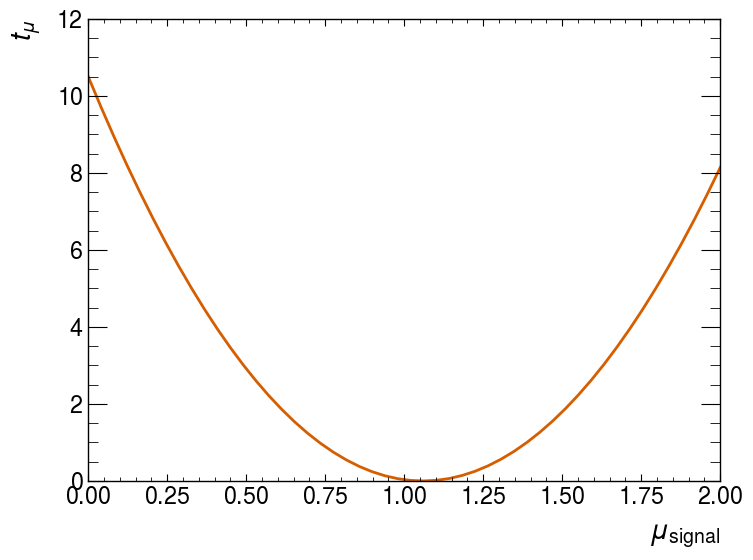

In [30]:
plt.plot(scan_points_nsbi, NLL_value_nsbi)
plt.axis(ymin=0)
plt.xlabel(r"$\mu_\mathrm{signal}$")
plt.ylabel(r"$t_\mu$")

### Systematic Uncertainty Modelling

So far we have left out the nuisance parameter piece of the parameterized density ratio decomposition shown in the slides:

$$\frac{p_s(x|\nu)}{p_s(x)}$$

which would require training density ratios for each "up" and "down" systematic variation. It can be done with additional notebooks and would require a workspace that looks like the following:

In [22]:
SYST_NAME = ""

def make_workspace_with_systematics():
    """Toy workspace for this example."""
    return {
        "channels": [{
            "name": "SR",
            "type": "unbinned",
            "weights": PATH_TO_WEIGHTS,
            "samples": [
                {"name": "signal",
                 "data": [TOTAL_YIELD["signal"]],
                 "ratios": PATH_TO_RATIOS["signal"],
                 "modifiers": [{"name": "mu", "type": "normfactor"},
                                {'name': SYST_NAME,
                                'data': {'hi_data': [TOTAL_YIELD["signal_SYST_NAME_UP"]],
                                    'hi_ratio': PATH_TO_RATIOS["signal_SYST_NAME_UP"],
                                    'lo_data': [TOTAL_YIELD["signal_SYST_NAME_DOWN"]],
                                    'lo_ratio': PATH_TO_RATIOS["signal_SYST_NAME_DOWN"]},
                                'type': 'normplusshape'}]},
                {"name": "background",
                 "data": [TOTAL_YIELD["background"]],
                 "ratios": PATH_TO_RATIOS["background"],
                 "modifiers": [{"name": "mu_bkg", "type": "normfactor"},
                                {'name': SYST_NAME,
                                'data': {'hi_data': [TOTAL_YIELD["background_SYST_NAME_UP"]],
                                    'hi_ratio': PATH_TO_RATIOS["background_SYST_NAME_UP"],
                                    'lo_data': [TOTAL_YIELD["background_SYST_NAME_DOWN"]],
                                    'lo_ratio': PATH_TO_RATIOS["background_SYST_NAME_DOWN"]},
                                'type': 'normplusshape'}]},
            ],
        }],
        # "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{
            "name": "meas",
            "config": {
                "poi": "mu",
                "parameters": [
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu"},
                    {"bounds": [[0, 10]], "inits": [1], "name": "mu_bkg"},
                ],
            },
        }],
        "version": "1.0.0",
    }
